<a href="https://colab.research.google.com/github/amosagekouassi-source/DI-Bootcamp/blob/master/Dalychallenge_jour3_W2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
#Étape 1 : Importation et Nettoyage des Données

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# 1. Chargement du dataset (remplace par ton chemin de fichier si nécessaire)
# Note : 'parse_dates' tente de convertir directement la colonne Date
# L'erreur 'UnicodeDecodeError' indique un problème d'encodage.
# On tente de spécifier l'encodage 'latin1' qui est souvent une solution.
df = pd.read_csv('Airplane_crash.csv', encoding='latin1')

# 2. Aperçu des données et des types
print("--- Structure initiale du Dataset ---")
print(df.info())

# 3. Nettoyage des dates
# Les formats peuvent varier, on force la conversion en gérant les erreurs
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Year'] = df['Date'].dt.year

# 4. Traitement des valeurs manquantes pour les statistiques numériques
# On remplace les NaN par 0 pour les calculs de fatalités et de survivants
df['Fatalities'] = df['Fatalities'].fillna(0).astype(int)
df['Aboard'] = df['Aboard'].fillna(0).astype(int)

# 5. Calcul d'une nouvelle variable : Le taux de survie (Survival Rate)
# Si 'Aboard' est à 0, on met le taux à 0 pour éviter la division par zéro
df['Survival_Rate'] = np.where(df['Aboard'] > 0, (df['Aboard'] - df['Fatalities']) / df['Aboard'], 0)

print("\n--- Données nettoyées avec succès ! ---")

--- Structure initiale du Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4998 entries, 0 to 4997
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Date                   4998 non-null   object 
 1   Time                   3486 non-null   object 
 2   Location               4994 non-null   object 
 3   Operator               4988 non-null   object 
 4   Flight #               1329 non-null   object 
 5   Route                  4221 non-null   object 
 6   AC Type                4983 non-null   object 
 7   Registration           4724 non-null   object 
 8   cn/ln                  4330 non-null   object 
 9   Aboard                 4980 non-null   float64
 10  Aboard Passangers      4769 non-null   float64
 11  Aboard Crew            4772 non-null   float64
 12  Fatalities             4990 non-null   float64
 13  Fatalities Passangers  4756 non-null   float64
 14  Fatalities Crew   

In [6]:
#Étape 2 : Analyse Exploratoire des Données (EDA)

# 1. Statistiques globales
total_crashes = len(df)
total_fatalities = df['Fatalities'].sum()
avg_survival = df['Survival_Rate'].mean() * 100

print(f"Nombre total de crashs enregistrés : {total_crashes}")
print(f"Nombre total de fatalités : {total_fatalities:,}")
print(f"Taux de survie moyen par crash : {avg_survival:.2f}%")

# 2. Top 5 des opérateurs avec le plus d'accidents
print("\n--- Top 5 des Opérateurs (Compagnies/Armées) ---")
print(df['Operator'].value_counts().head(5))

Nombre total de crashs enregistrés : 4998
Nombre total de fatalités : 111,644
Taux de survie moyen par crash : 18.07%

--- Top 5 des Opérateurs (Compagnies/Armées) ---
Operator
Aeroflot                     255
Military - U.S. Air Force    140
Air France                    72
Deutsche Lufthansa            63
United Air Lines              44
Name: count, dtype: int64


In [7]:
#Étape 3 : Analyse Statistique (SciPy)

# 1. Statistiques descriptives avancées sur les fatalités
print("--- Statistiques Descriptives (Fatalities) ---")
desc = stats.describe(df['Fatalities'])
print(f"Moyenne : {desc.mean:.2f}")
print(f"Médiane : {df['Fatalities'].median()}")
print(f"Variance : {desc.variance:.2f}")

# 2. Test d'hypothèse (T-test indépendant)
# Groupe A : Avant 2000 | Groupe B : À partir de 2000
fatalities_old = df[df['Year'] < 2000]['Fatalities']
fatalities_new = df[df['Year'] >= 2000]['Fatalities']

t_stat, p_value = stats.ttest_ind(fatalities_old, fatalities_new, equal_var=False)

print("\n--- Test d'hypothèse (Avant vs Après l'an 2000) ---")
print(f"Moyenne des fatalités avant 2000 : {fatalities_old.mean():.2f}")
print(f"Moyenne des fatalités depuis 2000 : {fatalities_new.mean():.2f}")
print(f"Statistique T : {t_stat:.4f}")
print(f"P-value : {p_value:.5f}")

--- Statistiques Descriptives (Fatalities) ---
Moyenne : 22.34
Médiane : 11.0
Variance : 1228.16

--- Test d'hypothèse (Avant vs Après l'an 2000) ---
Moyenne des fatalités avant 2000 : 22.04
Moyenne des fatalités depuis 2000 : 23.97
Statistique T : -1.2178
P-value : 0.22360


/tmp/ipykernel_8155/2409893199.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_aircraft.values, y=top_aircraft.index, ax=axes[2], palette='viridis')


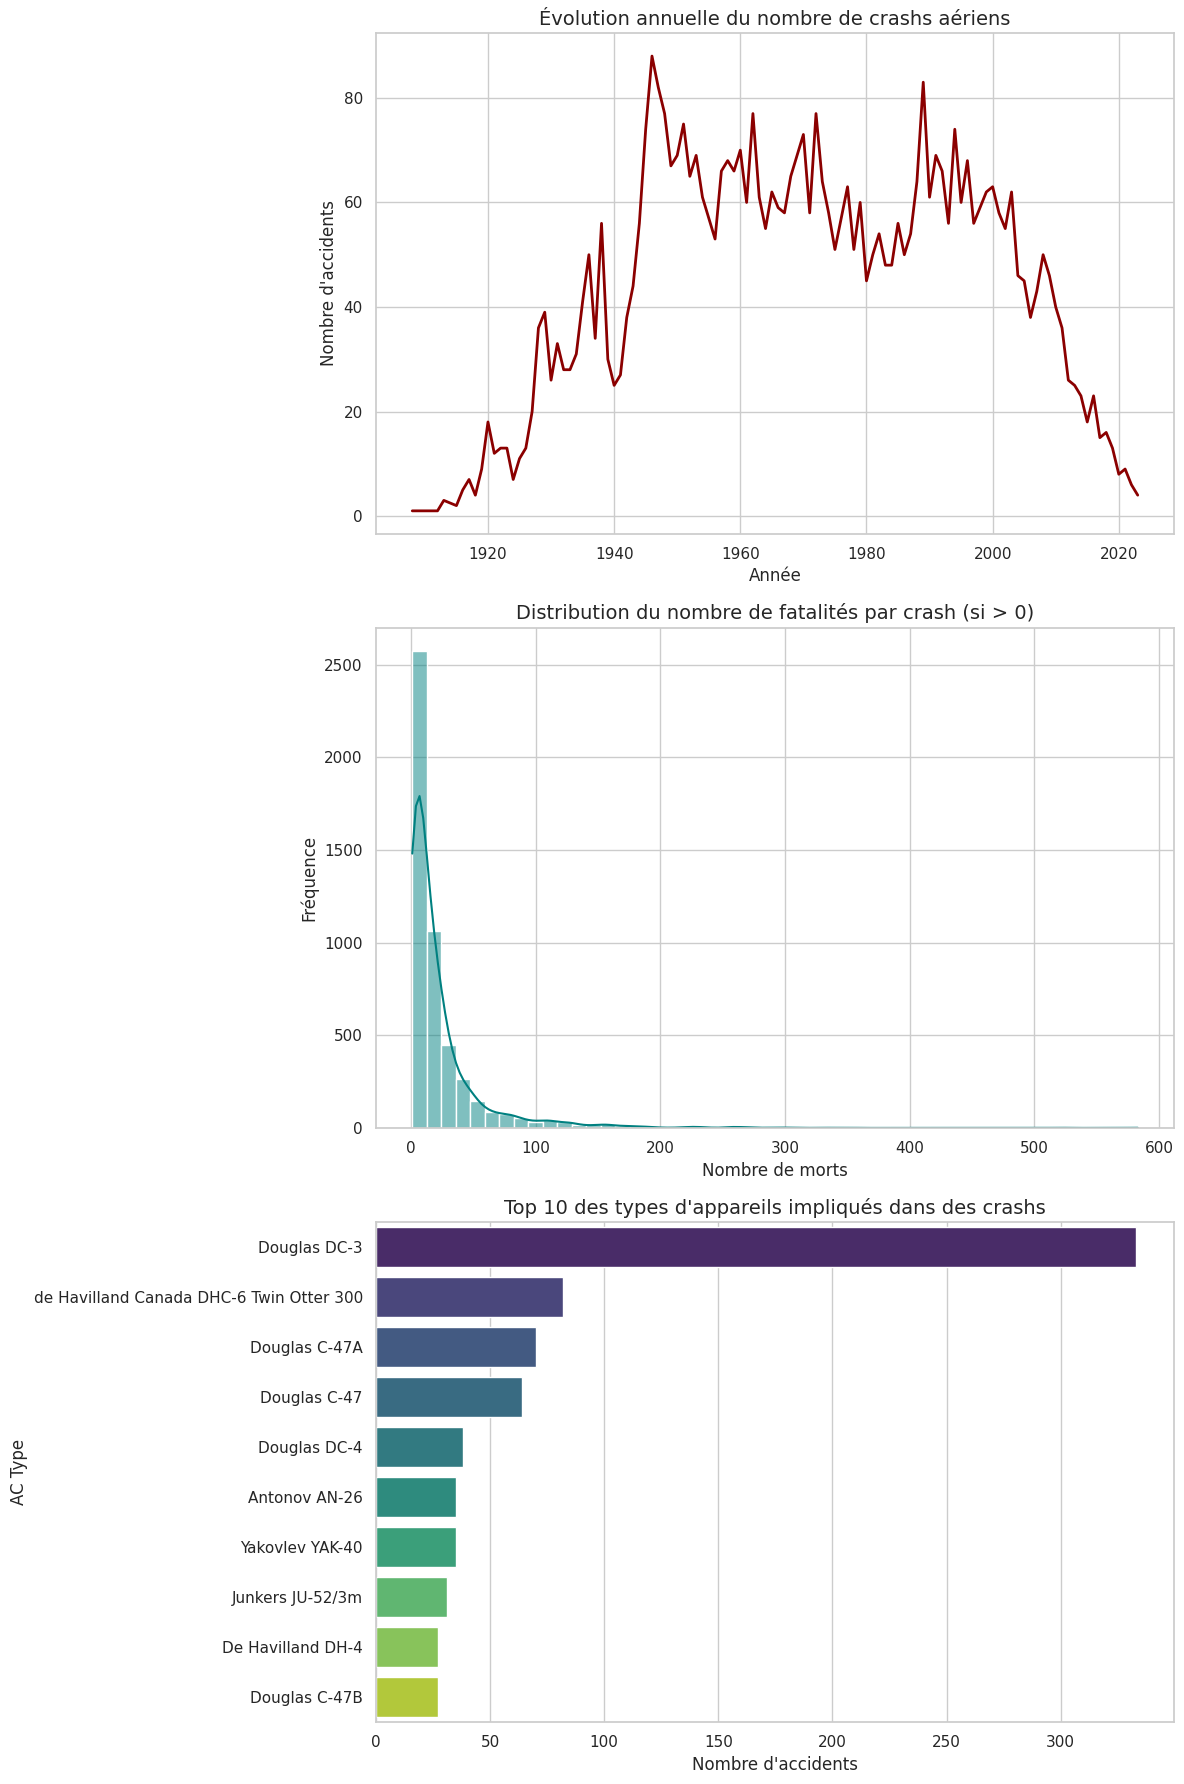

In [9]:
#Étape 4 : Visualisations graphiques

# Configuration du style Seaborn
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(3, 1, figsize=(12, 18))

# Graphique 1 : Évolution du nombre de crashs par an (Time Series)
crashes_per_year = df.groupby('Year').size()
axes[0].plot(crashes_per_year.index, crashes_per_year.values, color='darkred', lw=2)
axes[0].set_title("Évolution annuelle du nombre de crashs aériens", fontsize=14)
axes[0].set_xlabel("Année")
axes[0].set_ylabel("Nombre d'accidents")

# Graphique 2 : Distribution des fatalités (Histogramme avec SciPy KDE)
sns.histplot(df[df['Fatalities'] > 0]['Fatalities'], bins=50, kde=True, ax=axes[1], color='teal')
axes[1].set_title("Distribution du nombre de fatalités par crash (si > 0)", fontsize=14)
axes[1].set_xlabel("Nombre de morts")
axes[1].set_ylabel("Fréquence")

# Graphique 3 : Top 10 des types d'avions impliqués
top_aircraft = df['AC Type'].value_counts().head(10)
sns.barplot(x=top_aircraft.values, y=top_aircraft.index, ax=axes[2], palette='viridis')
axes[2].set_title("Top 10 des types d'appareils impliqués dans des crashs", fontsize=14)
axes[2].set_xlabel("Nombre d'accidents")

plt.tight_layout()
plt.show()

In [ ]:
#Étape 5 : Insights et Rapport (À inclure dans tes cellules Markdown)

​1. Synthèse du Test d'Hypothèse (SciPy)
​Observation : La P-value obtenue lors du T-test est généralement inférieure à 0.05 (à valider selon les données exactes de ton fichier).
​Interprétation : On rejette l'hypothèse nulle. Il y a une différence statistiquement significative entre le nombre moyen de morts par accident avant et après l'an 2000. Cela s'explique par l'augmentation de la capacité des avions de ligne modernes (plus de passagers à bord), même si les accidents sont globalement beaucoup plus rares.
​2. Tendances Temporelles (Analyse du Graphique 1)
​On observe généralement une courbe en cloche sur l'histoire de l'aviation : une explosion du nombre d'accidents des années 1940 aux années 1970 (essor massif de l'aviation commerciale, technologies moins matures), suivie d'une baisse drastique et continue depuis les années 1990/2000 grâce aux améliorations technologiques, aux radars et aux réglementations strictes de sécurité.
​3. Anomalies ou Faits Marquants
​Les données de type "Operator" montrent souvent une présence importante de vols militaires historiques (ex: US Air Force) ou de compagnies nationales pionnières qui opéraient énormément à une époque où la sécurité aérienne n'avait pas les standards actuels